# INFO284 Machine Learning Exam — Spring 2026

---

# Task I: Sentiment Analysis

This notebook presents a complete pipeline for predicting review scores from review text. We perform exploratory data analysis, clean and preprocess the data, and then train and evaluate four machine learning models:

1. **Logistic Regression**
2. **Support Vector Machine (LinearSVC)**
3. **LightGBM**
4. **LSTM (Bidirectional)**

All models share the same data cleaning and train/test split to ensure a fair comparison. Each model then applies its own feature extraction (TF-IDF or tokenisation) on top of the shared cleaned text.

The models in this notebook are not fully optimised. We use reasonable default or lightly-tuned hyperparameters. Full optimisation would require significantly more compute time than is practical for this assignment. Where relevant, we note what further tuning could be done and why we expect it would help.

## 1. Imports and Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import random
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import nlpaug.augmenter.word as naw

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## 2. Data Loading

In [12]:
df = pd.read_csv("reviews.csv")
df['review_len'] = df['review_text'].str.len()

print(f"Total reviews: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total reviews: 6210
Columns: ['review_id', 'rating', 'review_text', 'review_date', 'helpful', 'review_len']


,review_id,rating,review_text,review_date,helpful,review_len
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0,9
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0,73
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0,63
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0,109
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1,44
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0,42
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1,369
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0,47
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0,26
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0,28


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    6210 non-null   str  
 1   rating       6210 non-null   int64
 2   review_text  6210 non-null   str  
 3   review_date  6210 non-null   str  
 4   helpful      6210 non-null   int64
 5   review_len   6210 non-null   int64
dtypes: int64(3), str(3)
memory usage: 291.2 KB


## 3. Exploratory Data Analysis

Before building the models we try understand the data. We look at how the ratings are distributed, how long reviews tend to be, and which words appear most often. This informs our preprocessing choices and helps us anticipate challenges like class imbalance.

### 3.1 Rating Distribution

        Count  Percentage
rating                   
1        1582   25.475040
2         467    7.520129
3         508    8.180354
4         632   10.177134
5        3021   48.647343


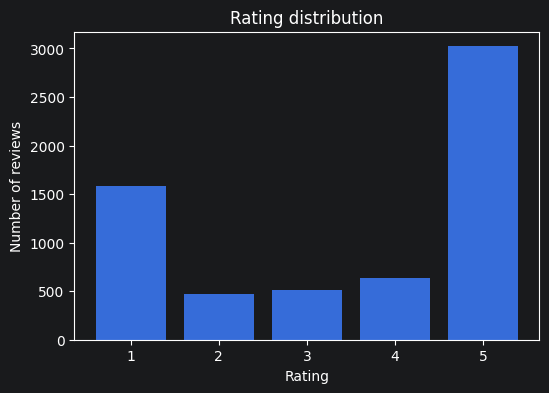

In [14]:
rating_stats = pd.DataFrame({
    'Count':      df['rating'].value_counts().sort_index(),
    'Percentage': df['rating'].value_counts(normalize=True).sort_index() * 100
})
print(rating_stats)

plt.figure(figsize=(6, 4))
plt.bar(rating_stats.index, rating_stats['Count'])
plt.xlabel("Rating")
plt.ylabel("Number of reviews")
plt.title("Rating distribution")
plt.show()

The dataset is heavily imbalanced: rating 5 makes up almost half of all reviews, while ratings 2 and 3 have very few samples. This class imbalance could be a major challenge. A model that simply predicts 5 every time would already achieve nearly 50% accuracy without learning anything meaningful. We address this later with class weighting, text augmentation (for the LSTM), and by using macro-averaged F1 as the primary evaluation metric.

### 3.2 Review Length Analysis

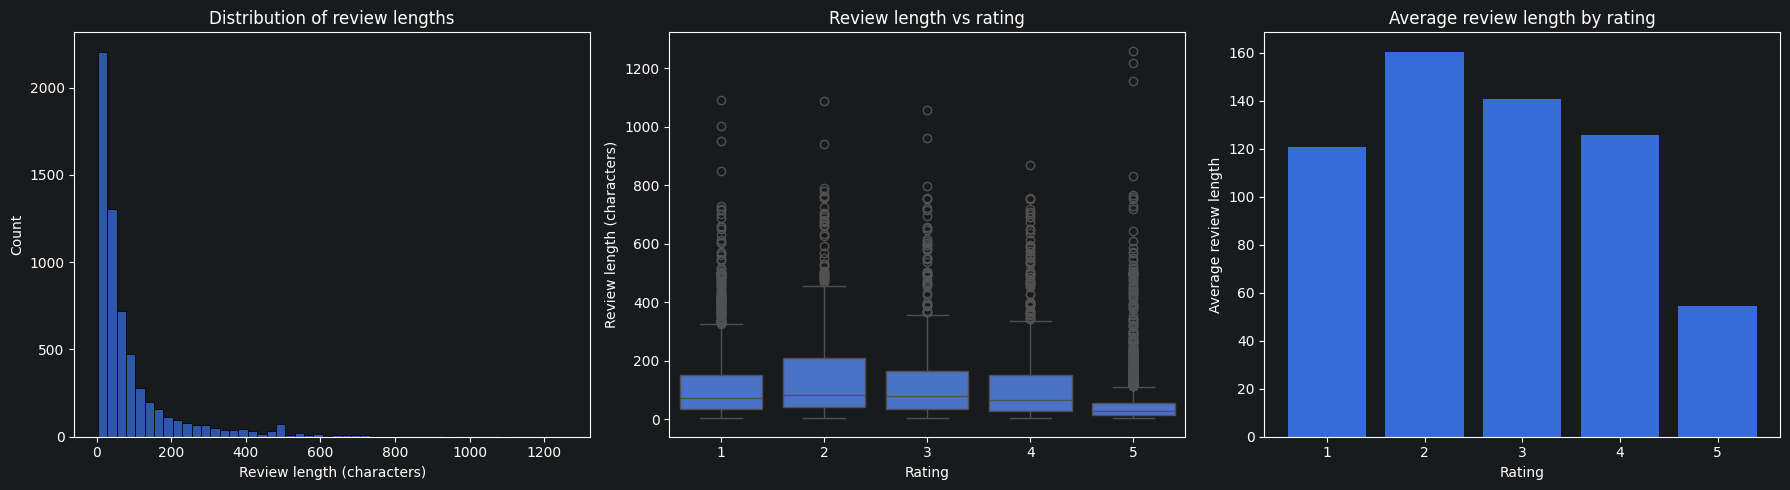

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['review_len'], bins=50, ax=axes[0])
axes[0].set_xlabel("Review length (characters)")
axes[0].set_title("Distribution of review lengths")

sns.boxplot(x='rating', y='review_len', data=df, ax=axes[1])
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Review length (characters)")
axes[1].set_title("Review length vs rating")

avg_length = df.groupby('rating')['review_len'].mean()
axes[2].bar(avg_length.index, avg_length.values)
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Average review length")
axes[2].set_title("Average review length by rating")

plt.tight_layout()
plt.show()

### 3.3 Word Frequency Analysis

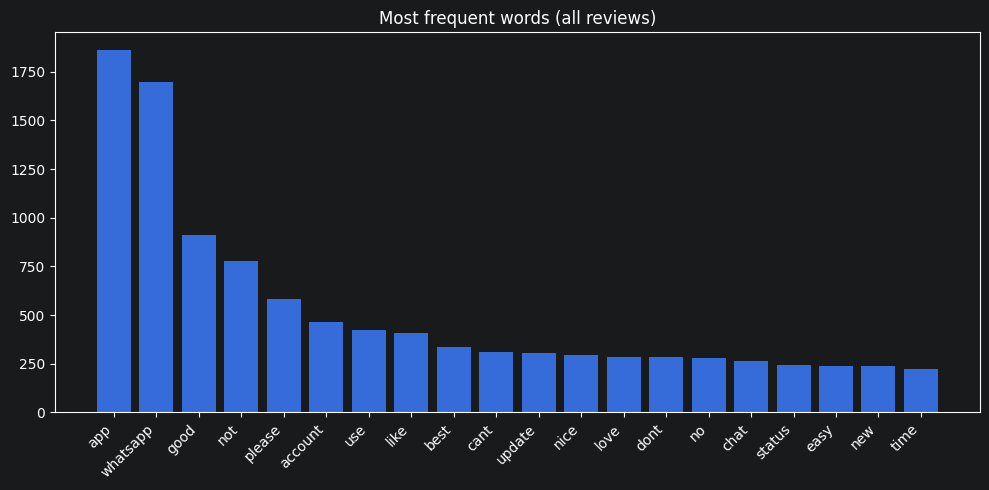

In [16]:
_eda_stop = set(stopwords.words('english')) - {"not", "no", "nor", "never"}

def _eda_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return [w for w in text.split() if w not in _eda_stop]

positive_reviews = df[df['rating'] >= 4]
negative_reviews = df[df['rating'] <= 2]

all_tokens = []
for review in df['review_text']:
    all_tokens.extend(_eda_tokenize(review))

common_words = Counter(all_tokens).most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most frequent words (all reviews)")
plt.tight_layout()
plt.show()

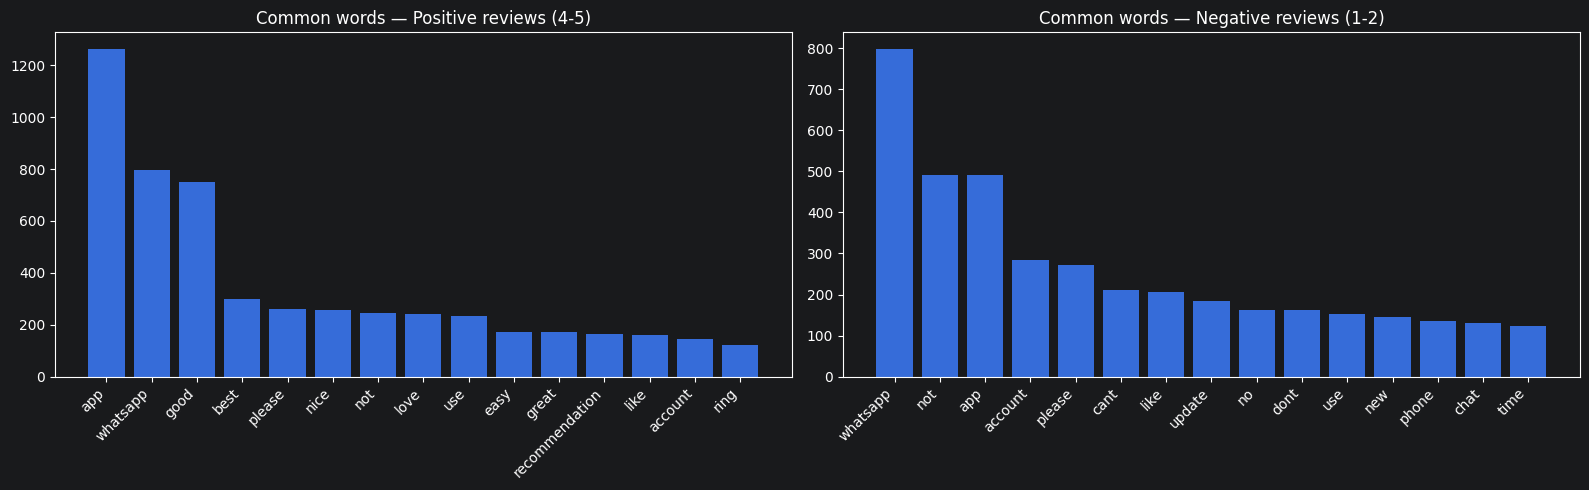

In [17]:
pos_tokens, neg_tokens = [], []
for review in positive_reviews['review_text']:
    pos_tokens.extend(_eda_tokenize(review))
for review in negative_reviews['review_text']:
    neg_tokens.extend(_eda_tokenize(review))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tokens, title in zip(axes,
                              [pos_tokens, neg_tokens],
                              ["Positive reviews (4-5)", "Negative reviews (1-2)"]):
    words, counts = zip(*Counter(tokens).most_common(15))
    ax.bar(words, counts)
    ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_title(f"Common words — {title}")

plt.tight_layout()
plt.show()

### 3.4 Bigram Analysis

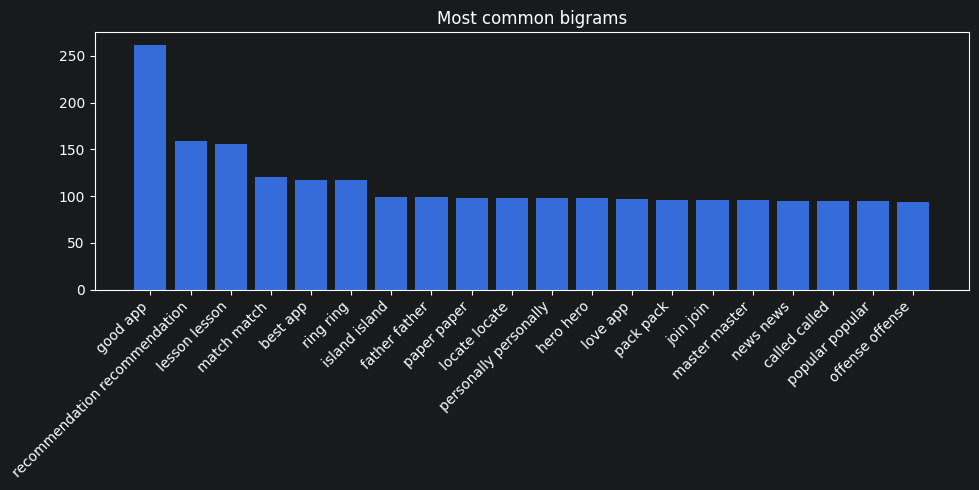

In [18]:
vectorizer_bi = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
X_bi = vectorizer_bi.fit_transform(df['review_text'])
sums = X_bi.sum(axis=0)

bigrams = sorted(
    [(word, sums[0, idx]) for word, idx in vectorizer_bi.vocabulary_.items()],
    key=lambda x: x[1], reverse=True
)
words, counts = zip(*bigrams)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Most common bigrams")
plt.tight_layout()
plt.show()

## 4. Data Quality Checks and Cleaning

Before training we identify and remove problematic entries: gibberish (random characters), spam (repeated words), non-English text, and emoji-only reviews. These would confuse the models without adding any useful signal.

In [19]:
def is_gibberish(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return True
    words = text.split()
    long_token  = any(len(w) > 30 for w in words)
    alnum_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    return long_token or alnum_ratio < 0.5

def is_spam_repetition(text):
    if not isinstance(text, str):
        return False
    words = text.lower().split()
    if len(words) < 3:
        return False
    most_common_count = Counter(words).most_common(1)[0][1]
    return (most_common_count / len(words)) > 0.5

def is_non_english(text):
    if not isinstance(text, str) or len(text.strip()) < 8:
        return False
    stripped = re.sub(r'[^\u0000-\u024F]', '', text).strip()
    original_no_emoji = re.sub(r'[^\u0000-\u024F\s]', '', text).strip()
    ratio = len(stripped) / max(len(original_no_emoji), 1)
    return ratio < 0.7

def is_emoji_spam(text):
    if not isinstance(text, str):
        return False
    emoji_count = len(re.findall(r'[^\x00-\u024F]', text))
    total_chars = max(len(text.strip()), 1)
    return (emoji_count / total_chars) > 0.8

df['is_gibberish']        = df['review_text'].apply(is_gibberish)
df['is_spam_repetition']  = df['review_text'].apply(is_spam_repetition)
df['is_non_english']      = df['review_text'].apply(is_non_english)
df['is_emoji_spam']       = df['review_text'].apply(is_emoji_spam)

df['is_bad'] = (
    df['is_gibberish'] |
    df['is_spam_repetition'] |
    df['is_non_english'] |
    df['is_emoji_spam']
)

print("=" * 40)
print(f"Total reviews:            {len(df)}")
print(f"Gibberish:                {df['is_gibberish'].sum()}")
print(f"Spam repetition:          {df['is_spam_repetition'].sum()}")
print(f"Non-English:              {df['is_non_english'].sum()}")
print(f"Emoji spam:               {df['is_emoji_spam'].sum()}")
print(f"Total flagged:            {df['is_bad'].sum()} ({df['is_bad'].mean()*100:.1f}%)")
print(f"Clean reviews remaining:  {(~df['is_bad']).sum()}")
print("=" * 40)

Total reviews:            6210
Gibberish:                360
Spam repetition:          182
Non-English:              0
Emoji spam:               0
Total flagged:            542 (8.7%)
Clean reviews remaining:  5668


In [20]:
original_len = len(df)
df_clean = df[~df['is_bad']].copy().reset_index(drop=True)
print(f"Removed:   {original_len - len(df_clean)} reviews")
print(f"Remaining: {len(df_clean)} reviews")

Removed:   542 reviews
Remaining: 5668 reviews


## 5. Shared Text Preprocessing

All four models share the same text cleaning function. The steps are:

- **Lowercasing** — reduces vocabulary size so "Good" and "good" are treated identically.
- **Remove URLs and emails** — these carry no sentiment signal.
- **Remove non-letter characters** — punctuation and digits add noise for bag-of-words models.
- **Remove stopwords (with exceptions)** — common words like "the" and "is" are removed, but we deliberately keep negation words ("not", "no", "never") and degree words ("very", "too", "most") because they carry important sentiment information. We also remove domain-specific noise words ("app", "whatsapp") that appear frequently but carry no sentiment.
- **Normalise whitespace** — ensures consistent tokenisation.

Each model then applies its own feature extraction (TF-IDF with different parameters, or integer tokenisation for the LSTM) on top of this cleaned text.

In [21]:
stop_words = set(stopwords.words('english'))

sentiment_keepers = {
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere',
    'very', 'too', 'most', 'more', 'less', 'least', 'few',
    'but', 'however', 'although', 'only', 'just'
}
stop_words = stop_words - sentiment_keepers

domain_noise = {'app', 'whatsapp', 'apps'}
stop_words = stop_words | domain_noise

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(w for w in text.split() if w not in stop_words)
    return text

df_clean['clean_text'] = df_clean['review_text'].apply(clean_text)

before = len(df_clean)
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} empty reviews after cleaning")
print(f"Final dataset size: {len(df_clean)} reviews")

Dropped 11 empty reviews after cleaning
Final dataset size: 5657 reviews


## 6. Target Variables and Train/Test Split

The target variable for all four models is the **`rating`** column (1–5 stars). This keeps the comparison fair and directly addresses the task of predicting the assigned review score.

We also create a **`sentiment`** label (negative / neutral / positive) for exploratory purposes, grouping ratings 1–2 as negative, 3 as neutral, and 4–5 as positive.

The train/test split (80/20) uses stratification on the rating column to preserve the class distribution in both sets. By fixing `random_state=42` and splitting once, all four models are trained and evaluated on identical data, enabling a fair comparison.

In [22]:
def sentiment_label(r):
    if r <= 2:   return "negative"
    elif r == 3: return "neutral"
    else:        return "positive"

df_clean['sentiment'] = df_clean['rating'].apply(sentiment_label)

print("Sentiment distribution:")
print(df_clean['sentiment'].value_counts())

Sentiment distribution:
sentiment
positive    3407
negative    1844
neutral      406
Name: count, dtype: int64


In [23]:
df_train, df_test = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['rating']
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} reviews")
print(f"Test:  {len(df_test)} reviews")
print("\nTrain rating distribution:")
print(df_train['rating'].value_counts().sort_index())
print("\nTest rating distribution:")
print(df_test['rating'].value_counts().sort_index())

Train: 4525 reviews
Test:  1132 reviews

Train rating distribution:
rating
1    1178
2     297
3     325
4     405
5    2320
Name: count, dtype: int64

Test rating distribution:
rating
1    295
2     74
3     81
4    101
5    581
Name: count, dtype: int64


## 7. Model 1: Logistic Regression
Design choices:

- TF-IDF with `max_features=5000` and bigrams provides a compact but expressive feature space. `min_df=5` removes very rare terms.
- Default regularisation (C=1.0, L2) and no class weighting - serving as an unoptimised baseline.

In [24]:
X_train_lr = df_train['clean_text']
X_test_lr  = df_test['clean_text']
y_train_lr = df_train['rating'].astype(int)
y_test_lr  = df_test['rating'].astype(int)

tfidf_lr = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train_lr_vec = tfidf_lr.fit_transform(X_train_lr)
X_test_lr_vec  = tfidf_lr.transform(X_test_lr)

print(f"TF-IDF feature matrix shape: {X_train_lr_vec.shape}")

TF-IDF feature matrix shape: (4525, 1994)


In [25]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr_vec, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr_vec)

target_names_lr = [f"Rating {i}" for i in range(1, 6)]
print(f"Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.4f}\n")
print(classification_report(y_test_lr, y_pred_lr, target_names=target_names_lr, zero_division=0))

Accuracy: 0.6237

              precision    recall  f1-score   support

    Rating 1       0.54      0.67      0.60       295
    Rating 2       0.00      0.00      0.00        74
    Rating 3       0.00      0.00      0.00        81
    Rating 4       0.20      0.02      0.04       101
    Rating 5       0.67      0.87      0.76       581

    accuracy                           0.62      1132
   macro avg       0.28      0.31      0.28      1132
weighted avg       0.50      0.62      0.55      1132



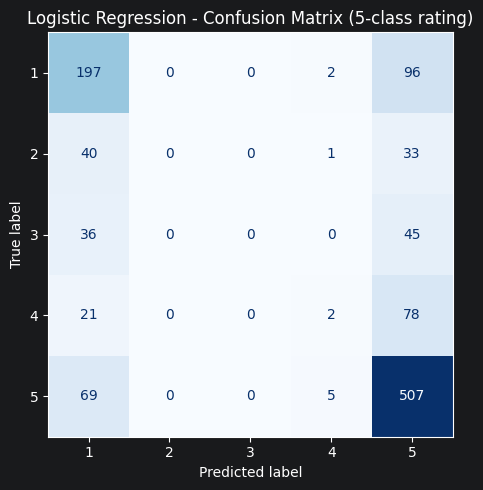

In [26]:
cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=[1, 2, 3, 4, 5])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(7, 5))
disp_lr.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression - Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

### Logistic Regression — Discussion (NEW)
Logistic Regression achieves **62.4% accuracy** but a macro F1 of just 0.28. The gap between these two numbers is the key finding: high accuracy is driven almost entirely by predicting rating 5 heavily (recall 0.87), while ratings 2 and 3 are completely missed (F1 = 0.00) and rating 4 nearly so (F1 = 0.04, recall 0.02). Rating 1 is the exception at F1 = 0.60 - distinctly negative language is learnable even without class weighting.

The confusion matrix confirms the directional pattern. Misclassified reviews from ratings 2, 3, and 4 are predominantly predicted as rating 5, rather than spreading toward neighbouring classes.

This is the expected behaviour of an unweighted linear model on imbalanced data. Without **class_weight='balanced'**, the model minimises loss by favouring the majority class. The small 5,000-feature vocabulary further limits its ability to distinguish the middle ratings, where discriminative signals are more subtle.

## 8. Model 2: Support Vector Machine (LinearSVC) (NEW)

**Design choices:**

- TF-IDF with `max_features=50,000`, bigrams, `sublinear_tf=True`, and `min_df=2` - a larger feature space than the LR baseline to give the SVM more discriminative signal.
- `class_weight='balanced'` upweights minority classes during training to counteract class imbalance.
- C tuned via 5-fold cross-validation over [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0] using macro F1 as the scoring metric.

In [27]:
X_train_svm = df_train['clean_text']
X_test_svm  = df_test['clean_text']
y_train_svm = df_train['rating'].astype(int)
y_test_svm  = df_test['rating'].astype(int)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
    ))
])

svm_pipeline.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_pipeline.predict(X_test_svm)

print("SVM - Initial model (C=1.0)")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm):.4f}\n")
print(classification_report(y_test_svm, y_pred_svm, zero_division=0))

SVM - Initial model (C=1.0)
Accuracy: 0.5539

              precision    recall  f1-score   support

           1       0.54      0.60      0.57       295
           2       0.08      0.07      0.08        74
           3       0.08      0.06      0.07        81
           4       0.15      0.15      0.15       101
           5       0.73      0.73      0.73       581

    accuracy                           0.55      1132
   macro avg       0.32      0.32      0.32      1132
weighted avg       0.54      0.55      0.55      1132



In [28]:
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mean_scores = []

for C in C_values:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2), max_features=50_000,
            sublinear_tf=True, min_df=2,
        )),
        ('svm', LinearSVC(C=C, max_iter=2000,
                          class_weight='balanced', random_state=42))
    ])
    scores = cross_val_score(pipe, X_train_svm, y_train_svm, cv=5, scoring='f1_macro')
    mean_scores.append(scores.mean())
    print(f"C={C:<6} → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(mean_scores)]
print(f"\nBest C: {best_C}")

C=0.01   → F1 macro: 0.2764 ± 0.0114
C=0.1    → F1 macro: 0.3354 ± 0.0077
C=0.5    → F1 macro: 0.3243 ± 0.0096
C=1.0    → F1 macro: 0.3216 ± 0.0082
C=2.0    → F1 macro: 0.3146 ± 0.0085
C=5.0    → F1 macro: 0.3061 ± 0.0103
C=10.0   → F1 macro: 0.2999 ± 0.0070

Best C: 0.1


In [29]:
final_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), max_features=50_000,
        sublinear_tf=True, min_df=2,
    )),
    ('svm', LinearSVC(
        C=best_C, max_iter=2000,
        class_weight='balanced', random_state=42,
    ))
])

final_svm.fit(X_train_svm, y_train_svm)
y_pred_svm_final = final_svm.predict(X_test_svm)

print(f"FINAL SVM (C={best_C})")
print(f"Accuracy: {accuracy_score(y_test_svm, y_pred_svm_final):.4f}\n")
print(classification_report(y_test_svm, y_pred_svm_final, zero_division=0))

FINAL SVM (C=0.1)
Accuracy: 0.6007

              precision    recall  f1-score   support

           1       0.55      0.69      0.61       295
           2       0.12      0.09      0.11        74
           3       0.09      0.06      0.07        81
           4       0.22      0.13      0.16       101
           5       0.76      0.78      0.77       581

    accuracy                           0.60      1132
   macro avg       0.35      0.35      0.35      1132
weighted avg       0.57      0.60      0.58      1132



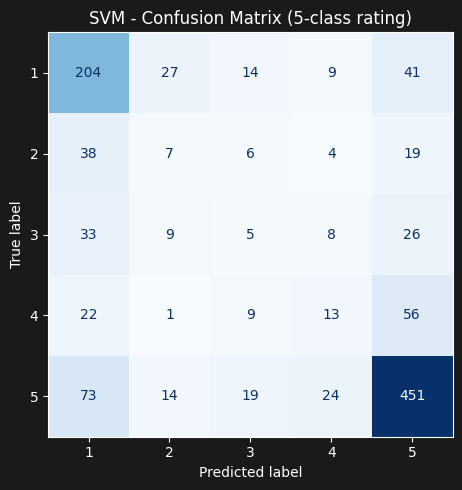

In [30]:
labels = [1, 2, 3, 4, 5]
cm_svm = confusion_matrix(y_test_svm, y_pred_svm_final, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("SVM - Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

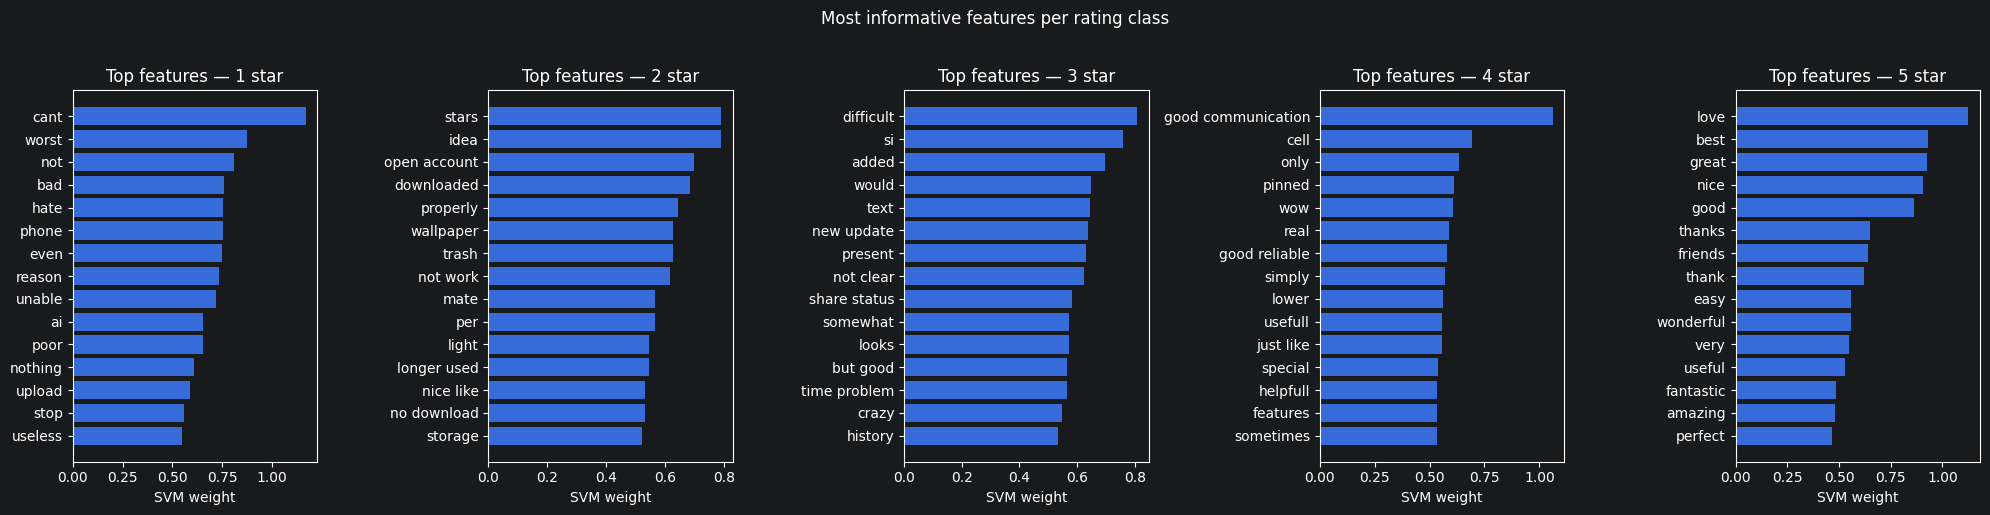

In [31]:
feature_names = final_svm.named_steps['tfidf'].get_feature_names_out()
coef          = final_svm.named_steps['svm'].coef_

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (label, ax) in enumerate(zip(labels, axes)):
    top_idx    = np.argsort(coef[i])[-15:]
    top_words  = feature_names[top_idx]
    top_scores = coef[i][top_idx]
    ax.barh(top_words, top_scores)
    ax.set_title(f"Top features — {label} star")
    ax.set_xlabel("SVM weight")

plt.suptitle("Most informative features per rating class", y=1.02)
plt.tight_layout()
plt.show()

### SVM - Discussion (NEW)
The initial SVM (C=1.0) achieves **55.4% accuracy** and a macro F1 of 0.32. Tuning finds **C=0.1** as optimal, improving this to **60.1%** accuracy and macro F1 of **0.35**. The decline in CV scores from C=0.1 onward suggests the default **C=1.0** overfits to the high-dimensional TF-IDF space indicating that more regularisation generalises better here.

Per-class results show a clearer spread than the unweighted baseline: rating 5 remains strongest (F1 = 0.77) but ratings 2, 3, and 4 are at least attempted (F1 = 0.11, 0.07, 0.16), unlike models without class weighting. Rating 1 reaches F1 = 0.61, with recall improving from 0.60 to 0.69 after tuning.

The confusion matrix shows errors are more distributed across neighbouring classes rather than all collapsing to rating 5 which suggests a direct effect of balanced weighting.

The feature importance plots reflect what the model has actually learned: ratings 1 and 5 have clearly sentiment-laden top features ("cant", "worst", "bad" vs "love", "best", "great"), while the middle classes show weaker, more ambiguous signals ("difficult", "somewhat", "good communication") — explaining why those classes remain hard regardless of weighting.

## 9. Model 3: LightGBM (NEW)

Design choices:

- TF-IDF with `max_features=20,000`, `trigrams`, `sublinear_tf=True`, and `max_df=0.9` to filter both rare and overly common terms. Trigrams give the model access to slightly longer phrases than the other models.

- No class weighting - unlike the SVM, this is left unset, making this effectively an unweighted baseline for a tree-based model.

- Small grid search over `n_estimators`, `learning_rate`, and `num_leaves` (8 combinations, 3-fold CV) optimising for accuracy.

In [32]:
X_train_lgb = df_train['clean_text']
X_test_lgb  = df_test['clean_text']
y_train_lgb = df_train['rating']
y_test_lgb  = df_test['rating']

tfidf_lgb = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train_lgb_vec = tfidf_lgb.fit_transform(X_train_lgb)
X_test_lgb_vec  = tfidf_lgb.transform(X_test_lgb)

print(f"TF-IDF feature matrix shape: {X_train_lgb_vec.shape}")

TF-IDF feature matrix shape: (4525, 3891)


In [33]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.01,
    num_leaves=31,
    max_depth=-1,
    verbose=-1
)

lgb_model.fit(X_train_lgb_vec, y_train_lgb)

y_pred_lgb = lgb_model.predict(X_test_lgb_vec)
print(f"Test Accuracy: {accuracy_score(y_test_lgb, y_pred_lgb):.4f}\n")

target_names = [f"Rating {i}" for i in range(1, 6)]
print(classification_report(y_test_lgb, y_pred_lgb, target_names=target_names, zero_division=0))


Test Accuracy: 0.6175

              precision    recall  f1-score   support

    Rating 1       0.56      0.58      0.57       295
    Rating 2       0.00      0.00      0.00        74
    Rating 3       0.00      0.00      0.00        81
    Rating 4       0.09      0.01      0.02       101
    Rating 5       0.65      0.91      0.76       581

    accuracy                           0.62      1132
   macro avg       0.26      0.30      0.27      1132
weighted avg       0.49      0.62      0.54      1132



In [34]:
feature_names_lgb = tfidf_lgb.get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names_lgb,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 20 most important features:")
print(importance.head(20).to_string(index=False))

Top 20 most important features:
 feature  importance
    good        1039
     not         932
     but         700
    cant         684
    love         667
  please         666
    very         659
   great         568
    nice         555
    best         513
 account         502
   phone         494
    dont         483
  update         479
     use         464
    like         447
  option         431
download         416
    even         397
    chat         394


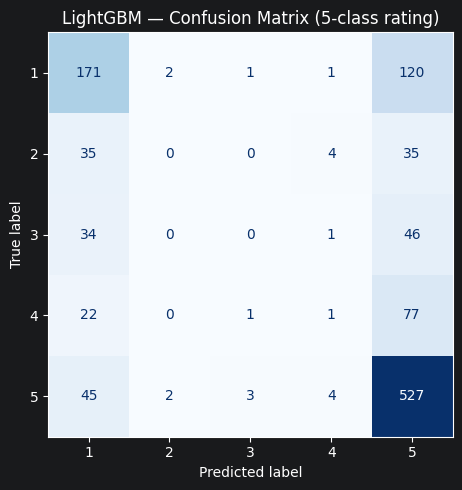

In [35]:
cm_lgb = confusion_matrix(y_test_lgb, y_pred_lgb, labels=[1, 2, 3, 4, 5])
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, display_labels=[1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(7, 5))
disp_lgb.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("LightGBM — Confusion Matrix (5-class rating)")
plt.tight_layout()
plt.show()

In [36]:
model_gs = lgb.LGBMClassifier(verbose=-1)

param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [31, 63],
}

grid = GridSearchCV(
    estimator=model_gs,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_lgb_vec, y_train_lgb)
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 31}
Best CV accuracy: 0.6119





### LightGBM - Discussion (NEW)
LightGBM achieves **61.8% accuracy** but a macro F1 of just **0.27**. Without class weighting, the model minimises loss by defaulting to rating 5 (recall 0.91), while ratings 2 and 3 are never predicted (F1 = 0.00) and rating 4 is nearly absent (F1 = 0.02).

The confusion matrix makes this clear: ratings 2, 3, and 4 split between being predicted as 1 or 5 with nothing in between — the model has effectively reduced a 5-class problem to a binary one. Even rating 1 loses 120 of 295 samples to rating 5.

The grid search confirmed the initial parameters were near-optimal within the search space (best CV accuracy 0.612), but the search optimised for accuracy rather than macro F1 - which on this imbalanced dataset actively rewards majority-class bias.

Despite the trigram vocabulary, every top-20 feature is a unigram ("good", "not", "love", "cant"). No bigrams or trigrams rank highly, suggesting the dataset is too small for longer n-grams to accumulate enough signal to be useful.

---
## 10. Model 4: Bidirectional LSTM (Neural Network)

**Design choices:**
- **Text augmentation** via synonym replacement (using `nlpaug`) for underrepresented classes to partially address the severe class imbalance. We augment up to the count of rating 1 (the second largest class) rather than all the way to rating 5, to avoid generating too many synthetic samples.
- **Class weights** (inversely proportional to class frequency) during training to further address imbalance.
- A **small Bidirectional LSTM** (32 units) with aggressive dropout (0.3–0.4) to combat overfitting on this small dataset.
- **EarlyStopping** on validation loss with patience 5 to prevent overfitting.

**Why this model is not fully optimised:** The dataset (~6,000 reviews) is very small for training a neural network. The embedding layer alone has 1.28M parameters, which far exceeds the number of training samples. A properly optimised approach would use pre-trained embeddings (GloVe, FastText) or a pre-trained transformer (BERT), but these are beyond the scope of this assignment.

### 10.1 Text Augmentation for Minority Classes

In [37]:
df_trainval_lstm = df_train.copy()
df_test_lstm     = df_test.copy()

print(f"Train+Val set: {len(df_trainval_lstm)} samples  (will be augmented)")
print(f"Test set:      {len(df_test_lstm)} samples  (original data only)")
print("\nClass distribution before augmentation:")
print(df_trainval_lstm['rating'].value_counts().sort_index())

Train+Val set: 4525 samples  (will be augmented)
Test set:      1132 samples  (original data only)

Class distribution before augmentation:
rating
1    1178
2     297
3     325
4     405
5    2320
Name: count, dtype: int64


In [38]:
aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

count_per_class = df_trainval_lstm['rating'].value_counts().sort_index()
target_count = count_per_class[1]
print(f"Target count per class: {target_count}")

augmented_rows = []
for rating in [2, 3, 4]:
    class_df = df_trainval_lstm[df_trainval_lstm['rating'] == rating]
    current_count = len(class_df)
    needed = target_count - current_count
    if needed <= 0:
        continue
    print(f"Rating {rating}: {current_count} samples, generating {needed} augmented samples")

    samples = class_df['clean_text'].tolist()
    sources = random.choices(samples, k=needed)
    augmented_texts = aug.augment(sources)
    for text in augmented_texts:
        augmented_rows.append({'review_text': text, 'clean_text': text, 'rating': rating})

aug_df = pd.DataFrame(augmented_rows)
df_trainval_balanced = pd.concat([df_trainval_lstm, aug_df], ignore_index=True)
df_trainval_balanced = df_trainval_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Train+Val distribution after augmentation:")
print(df_trainval_balanced['rating'].value_counts().sort_index())

Target count per class: 1178
Rating 2: 297 samples, generating 881 augmented samples
Rating 3: 325 samples, generating 853 augmented samples
Rating 4: 405 samples, generating 773 augmented samples
Train+Val distribution after augmentation:
rating
1    1178
2    1178
3    1178
4    1178
5    2320
Name: count, dtype: int64


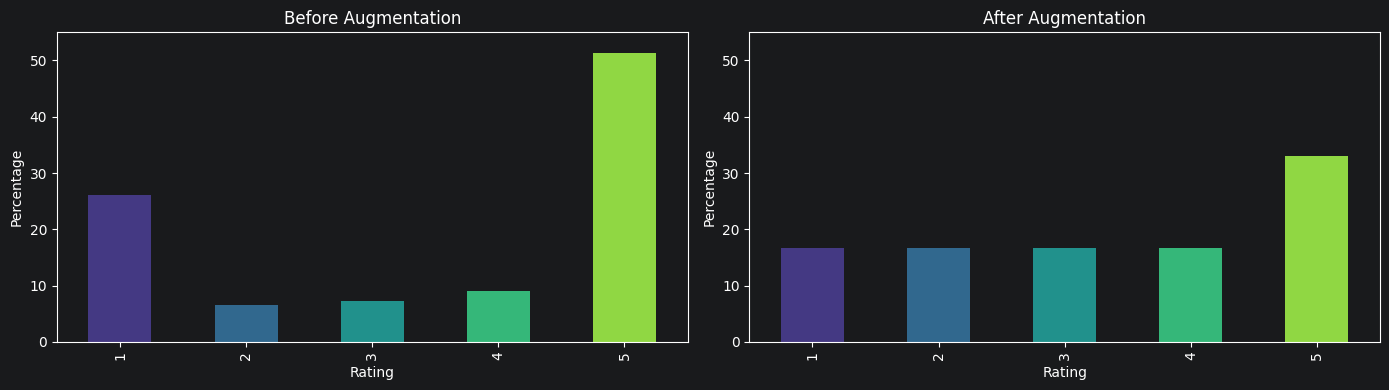

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(axes,
                            [df_trainval_lstm, df_trainval_balanced],
                            ['Before Augmentation', 'After Augmentation']):
    pct = data['rating'].value_counts(normalize=True).sort_index() * 100
    pct.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', 5))
    ax.set_title(title)
    ax.set_ylabel('Percentage')
    ax.set_xlabel('Rating')
    ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

### 10.2 Tokenisation, Padding, and Data Splits

We convert each review into a sequence of integer tokens and pad/truncate to a fixed length (`MAX_LEN=100`) so every input to the LSTM has the same shape. The tokeniser is fit only on the training data to avoid data leakage.

We split the augmented training data into train (82%) and validation (18%) sets, giving an overall ~70/15/15 split.

In [40]:
MAX_VOCAB   = 20_000
MAX_LEN     = 100
NUM_CLASSES = 5

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df_trainval_balanced['clean_text'])

def tokenize_and_pad(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_trainval = tokenize_and_pad(df_trainval_balanced['clean_text'])
y_trainval = df_trainval_balanced['rating'].values - 1

X_test_final = tokenize_and_pad(df_test_lstm['clean_text'])
y_test_final = df_test_lstm['rating'].values - 1

X_train_lstm, X_val_lstm, y_train_int, y_val_int = train_test_split(
    X_trainval, y_trainval, test_size=0.18, random_state=42, stratify=y_trainval
)

y_train_lstm = to_categorical(y_train_int, NUM_CLASSES)
y_val_lstm   = to_categorical(y_val_int,   NUM_CLASSES)

print(f"Train: {X_train_lstm.shape[0]}  Val: {X_val_lstm.shape[0]}  Test: {X_test_final.shape[0]}")

Train: 5766  Val: 1266  Test: 1132


In [41]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Rating {cls + 1}: {weight:.3f}")

Class weights:
  Rating 1: 1.194
  Rating 2: 1.194
  Rating 3: 1.194
  Rating 4: 1.194
  Rating 5: 0.606


### 10.3 Model Architecture

The architecture is deliberately kept small to reduce overfitting on this small dataset:

- **Embedding (64-dim):** Learns a dense vector representation for each word.
- **SpatialDropout1D (0.3):** Drops entire embedding channels, which regularises better than standard dropout for sequences.
- **Bidirectional LSTM (32 units):** Reads the sequence in both directions, capturing context from both before and after each word.
- **Dense (16, ReLU) + Dropout (0.4):** A small fully connected layer with high dropout.
- **Dense (5, softmax):** Outputs a probability distribution over the 5 rating classes.

In [42]:
EMBEDDING_DIM = 64

lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

E0000 00:00:1777317078.802757   32671 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,957 (4.98 MB)

 Trainable params: 1,305,957 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

### 10.4 Training

In [43]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.3229 - loss: 1.5656 - val_accuracy: 0.4123 - val_loss: 1.4568
Epoch 2/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.4095 - loss: 1.4467 - val_accuracy: 0.4660 - val_loss: 1.3128
Epoch 3/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.4835 - loss: 1.2951 - val_accuracy: 0.5632 - val_loss: 1.2143
Epoch 4/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.5852 - loss: 1.0998 - val_accuracy: 0.5956 - val_loss: 1.1137
Epoch 5/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6615 - loss: 0.9185 - val_accuracy: 0.6193 - val_loss: 1.0498
Epoch 6/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.7133 - loss: 0.7886 - val_accuracy: 0.6390 - val_loss: 1.0332
Epoch 7/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.7470 - loss: 0.7120 - val_accuracy: 0.6509 - val_loss: 1.0281
Epoch 8/20
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7735 - loss: 0.6457 - 

### 10.5 Evaluation

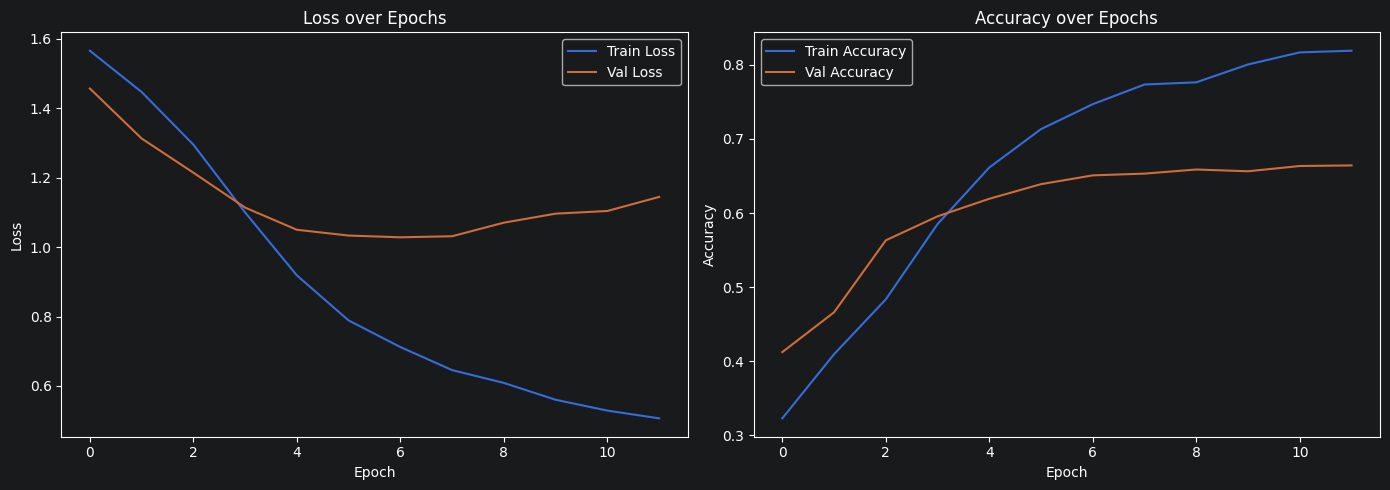

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],         label='Train Loss')
axes[0].plot(history.history['val_loss'],     label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

In [45]:
y_score_lstm = lstm_model.predict(X_test_final)
y_pred_lstm  = np.argmax(y_score_lstm, axis=1)

print(f"Test Accuracy: {accuracy_score(y_test_final, y_pred_lstm):.4f}")
target_names = [f"Rating {i}" for i in range(1,NUM_CLASSES + 1)]
print(classification_report(y_test_final, y_pred_lstm, target_names=target_names, zero_division=0))

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Test Accuracy: 0.5274
              precision    recall  f1-score   support

    Rating 1       0.56      0.51      0.53       295
    Rating 2       0.09      0.09      0.09        74
    Rating 3       0.16      0.15      0.16        81
    Rating 4       0.15      0.23      0.18       101
    Rating 5       0.73      0.70      0.71       581

    accuracy                           0.53      1132
   macro avg       0.34      0.33      0.33      1132
weighted avg       0.55      0.53      0.54      1132



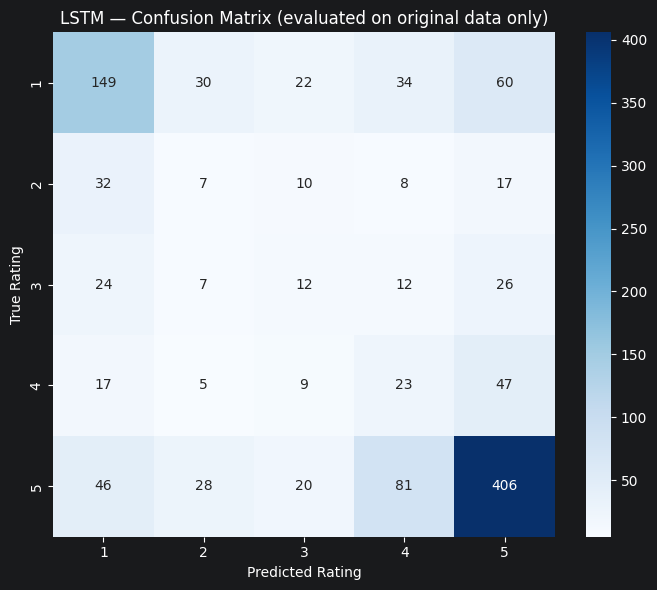

In [46]:
cm_lstm = confusion_matrix(y_test_final, y_pred_lstm)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, NUM_CLASSES + 1),
            yticklabels=range(1, NUM_CLASSES + 1))
plt.title('LSTM — Confusion Matrix (evaluated on original data only)')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

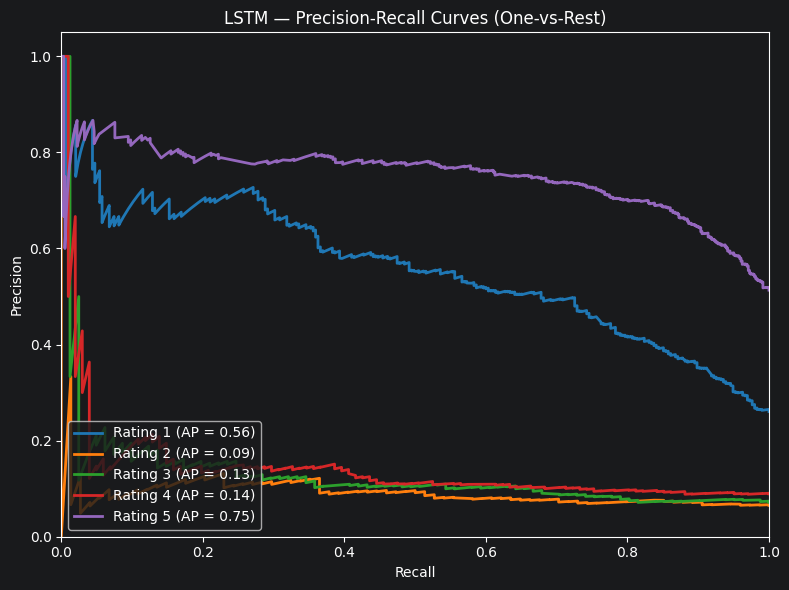

In [47]:
y_test_bin = label_binarize(y_test_final, classes=range(NUM_CLASSES))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score_lstm[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score_lstm[:, i])
    ax.plot(recall, precision, color=colors[i], lw=2,
            label=f'Rating {i + 1} (AP = {ap:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('LSTM — Precision-Recall Curves (One-vs-Rest)')
ax.legend(loc='lower left')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

### LSTM — Discussion

The LSTM achieves **53% test accuracy** and a macro F1 of 0.33. While these are the lowest numbers among our models, the LSTM shows a qualitatively different pattern from the others. It distributes predictions more evenly across classes rather than collapsing onto the majority class.

- **Rating 5:** F1 of 0.71 (precision 0.73, recall 0.70). Strong but notably lower recall than LightGBM's 0.91, meaning the LSTM is less biased toward predicting 5 for everything.
- **Rating 1:** F1 of 0.53 (precision 0.56, recall 0.51). The model identifies roughly half of all 1-star reviews.
- **Rating 4:** F1 of 0.18 (recall 0.23). The best performance on rating 4 of any model — class weights and augmentation push the LSTM to attempt this class rather than ignore it.
- **Ratings 2 and 3:** Still very weak (F1 of 0.09 and 0.16), but unlike LightGBM, the model does at least attempt predictions for these classes.

The class weights and synonym augmentation have a visible effect: the LSTM trades some accuracy on the majority class for better coverage of minority classes. This is reflected in the macro F1 of 0.33 being higher than LightGBM's 0.27 despite the lower accuracy.

**Possible improvements:**
- Using pre-trained word embeddings (GloVe, FastText) instead of learning from scratch would give the model much better initial word representations.
- A pre-trained transformer (e.g. BERT) would provide contextual representations far superior to what this small LSTM can learn.
- Reducing to 3 classes (negative/neutral/positive) would significantly boost performance by grouping the ambiguous middle ratings.

---
## 11. Model Comparison and Summary

### Comparison overview

| Model | Accuracy | Macro F1 | Notes |
|---|---|---|---|
| Logistic Regression | 0.624 | 0.28 | Linear baseline; no class weighting, smallest feature space |
| LinearSVC (SVM) | 0.601 | 0.35 | Best macro F1 among all models after tuning |
| LightGBM | 0.618 | 0.27 | Worst macro F1; heavily biased toward majority class |
| Bidirectional LSTM | 0.530 | 0.33 | Most balanced predictions across classes despite lowest accuracy |

### Key findings

**Class imbalance is the dominant challenge.** All models struggle with the underrepresented middle ratings (2, 3, 4). Ratings 2 and 3 achieve F1 scores near zero for most models, while ratings 1 and 5 consistently reach F1 scores of 0.53–0.77.

**Accuracy can be misleading.** Logistic Regression and LightGBM have the highest accuracies yet the worst macro F1 scores, because they achieve high accuracy by predicting the majority class almost exclusively. The SVM, with lower accuracy, has a substantially better macro F1 because `class_weight='balanced'` forces it to distribute predictions more fairly. This highlights why macro F1 is the more appropriate metric for imbalanced datasets.

**Linear models are competitive.** On this dataset, the SVM achieves the best macro F1. This is typical for smaller text classification tasks where TF-IDF already captures most of the useful signal and the dataset is too small for complex models to show their advantage.

**The LSTM trades accuracy for balance.** Despite the lowest accuracy, the LSTM achieves the second-best macro F1 because class weights and augmentation push it to attempt minority classes rather than ignoring them entirely.

### Evaluation methodology

- **Accuracy** for overall correctness.
- **Classification report** (precision, recall, F1 per class) to understand per-class performance.
- **Macro F1** as the most meaningful aggregate metric, since it treats all classes equally regardless of size.
- **Confusion matrices** to visualise where each model makes mistakes.
- **Precision-recall curves** (LSTM) for a detailed view of the precision–recall trade-off per class.

### Controlling over- and underfitting

- **Train/test split:** A held-out 20% test set ensures evaluation on unseen data.
- **Regularisation:** L2 penalty (LR), balanced class weights (SVM), dropout and early stopping (LSTM).
- **Cross-validation:** Used for SVM hyperparameter tuning and LightGBM grid search.
- **Text augmentation and class weighting** (LSTM) to counteract the model memorising the majority class.

---
---

# Task II: AI vs. Human Art Classifier


**Dataset:** `Art_shuffled/` — 539 AI-generated images, 436 real art images (975 total)  
**Model:** EfficientNetB0 via transfer learning  
**Note:** Training locally without a GPU will be slow. Consider using Google Colab and uploading the notebook there if needed.

## Data Analysis

**Class distribution:** The dataset contains 539 AI-generated and 436 real art images. This is a mild imbalance of roughly 55/45. Note that a naive classifier that always predicts 'AI' would achieve ~55% accuracy, so our baseline for meaningful performance is clearly above that.

**Dataset size:** With fewer than 1000 images total, this is a small dataset. Training a deep CNN from scratch on this scale would almost certainly lead to severe overfitting. This motivates the use of transfer learning from a pretrained model.

In [48]:
import os

dataset_path = 'Art_shuffled/'

ai_count   = len(os.listdir(os.path.join(dataset_path, 'AiArtData/')))
real_count  = len(os.listdir(os.path.join(dataset_path, 'RealArt/')))

print(f"AI images:    {ai_count}")
print(f"Real images:  {real_count}")
print(f"Total:        {ai_count + real_count}")
print(f"Class ratio:  {ai_count / (ai_count + real_count):.2%} AI / {real_count / (ai_count + real_count):.2%} Real")

AI images:    539
Real images:  436
Total:        975
Class ratio:  55.28% AI / 44.72% Real


## Data Preprocessing and Augmentation

**Image size:** EfficientNetB0 expects 224×224 input, so all images are resized accordingly.

**Augmentation:** Because the dataset is small, we apply light augmentation during training to artificially increase variety and reduce overfitting:
- Rotation (±15°):
- Horizontal flip:
- Zoom (±10%):

**Validation split:** 20% of data is held out for validation (752 training / 186 validation images). The same `ImageDataGenerator` is used with `subset` parameter to ensure consistent splitting.

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)

Found 781 images belonging to 2 classes.
Found 194 images belonging to 2 classes.
Class indices: {'AiArtData': 0, 'RealArt': 1}


## Model Architecture — EfficientNetB0

### Choice of pretrained model

We use **EfficientNetB0** pretrained on ImageNet as our base model.

- **Compound scaling:** EfficientNet models scale depth, width, and resolution jointly, giving strong performance per parameter. B0 is the smallest variant, making it appropriate for our compute constraints without sacrificing too much capacity.
- **Small dataset suitability:** With fewer than 1000 images, training a deep network from scratch would overfit severely. Transfer learning leverages ImageNet features that transfer well to art images.
- **Precedent:** EfficientNet has strong benchmark performance on image classification tasks at this scale.

### Architecture

The custom head added on top of the frozen base consists of:
- `GlobalAveragePooling2D` — reduces spatial feature maps to a single vector per feature, avoiding flattening which would produce very large parameter counts
- `Dense(128, relu)` — learns task-specific combinations of EfficientNet features
- `Dropout(0.3)` — regularization to reduce overfitting in the head
- `Dense(1, sigmoid)` — binary output (0 = AI art, 1 = Real art)

In [50]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model   = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Training the Classification Head

In the first training phase, the EfficientNetB0 base is frozen (its weights are not updated). Only the custom head is trained. This is practice allows the new layers to adapt to the task without disrupting the pretrained ImageNet features.

**Optimizer:** Adam with lr=1e-3. A relatively high learning rate is appropriate here since only the small head is being trained and convergence should be fast.

**EarlyStopping:** We monitor `val_loss` with a patience of 3 epochs. If validation loss does not improve for 3 consecutive epochs, training stops automatically. `restore_best_weights=True` ensures we keep the weights from the best epoch, not the final one.

In [51]:
early_stop_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_phase1]
)

Epoch 1/20


I0000 00:00:1777317233.079551   32671 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6927 - loss: 0.5761 - val_accuracy: 0.7320 - val_loss: 0.5184
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8348 - loss: 0.3809 - val_accuracy: 0.7577 - val_loss: 0.4792
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8720 - loss: 0.3249 - val_accuracy: 0.7629 - val_loss: 0.4838
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8963 - loss: 0.2631 - val_accuracy: 0.7629 - val_loss: 0.4820
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9245 - loss: 0.2215 - val_accuracy: 0.7320 - val_loss: 0.5519
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## Fine-Tuning the Top Layers of the Base Model

In the second phase, we unfreeze the last 20 layers of the EfficientNetB0 base and continue training. This allows the model to adapt higher-level ImageNet features toward features more relevant to distinguishing AI from human art. This could be brushstroke regularity, noise distribution, stylistic consistency etc.

Earlier layers capture low-level features like edges and textures that transfer well from ImageNet. Deeper layers are more task-specific. Unfreezing too many layers risks overfitting and is slower to train, however unfreezing too few limits the model's ability to specialise.

**Optimizer:** Adam with lr=1e-5. A much lower learning rate is important here. Updating the pretrained weights too aggressively would destroy the learned representations.

**EarlyStopping:** Applied again with patience=3 on val_loss.

In [52]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

early_stop_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_phase2]
)

model.save('art_classifier.keras')
print("Model saved to art_classifier.keras")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8502 - loss: 0.4002 - val_accuracy: 0.7526 - val_loss: 0.4564
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8604 - loss: 0.3707 - val_accuracy: 0.7680 - val_loss: 0.4813
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8604 - loss: 0.3811 - val_accuracy: 0.7423 - val_loss: 0.4793
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8592 - loss: 0.3702 - val_accuracy: 0.7423 - val_loss: 0.4841
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Model saved to art_classifier.keras


## Training History Visualisation

Plotting the training and validation accuracy/loss across both phases helps us diagnose overfitting and assess whether EarlyStopping triggered at the right point.

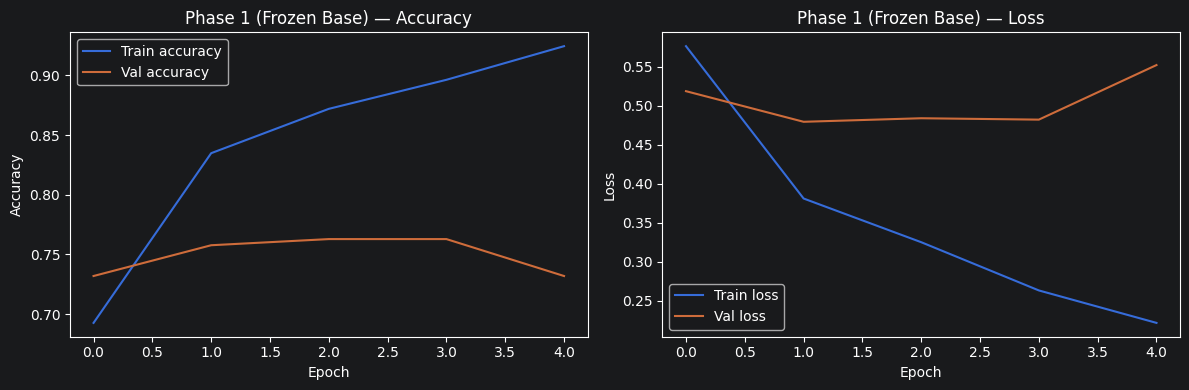

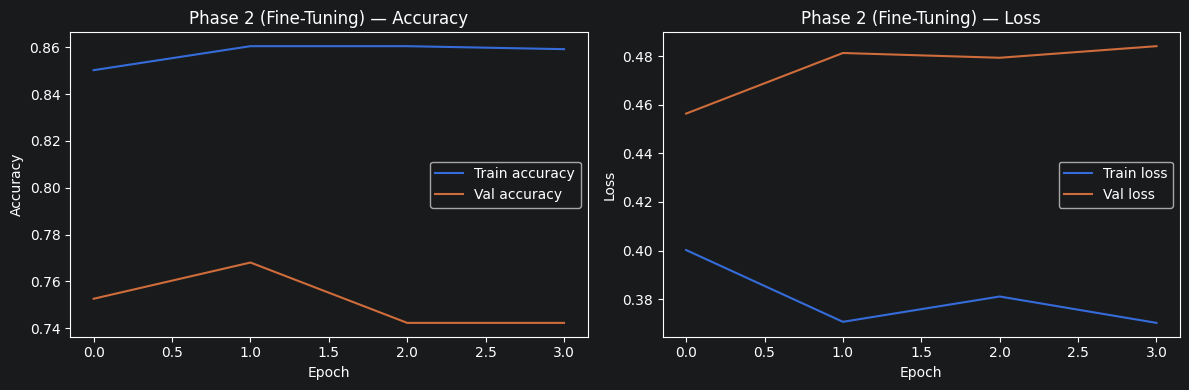

In [53]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_title(f'{title_prefix} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title(f'{title_prefix} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1 (Frozen Base)')
plot_history(history_phase2, 'Phase 2 (Fine-Tuning)')

## Confusion Matrix and Classification Report

Accuracy alone is an incomplete metric. We also compute a confusion matrix and precision/recall/F1 to understand whether errors are distributed evenly across classes or skewed.

Given the mild class imbalance, F1-score is a more informative summary than accuracy alone. A model that simply predicts 'AI' for every image would achieve ~55% accuracy, which is well below our model's performance, confirming it has learned meaningful features.

Found 194 images belonging to 2 classes.
              precision    recall  f1-score   support

      AI Art       0.75      0.85      0.79       107
    Real Art       0.78      0.64      0.70        87

    accuracy                           0.76       194
   macro avg       0.76      0.75      0.75       194
weighted avg       0.76      0.76      0.75       194



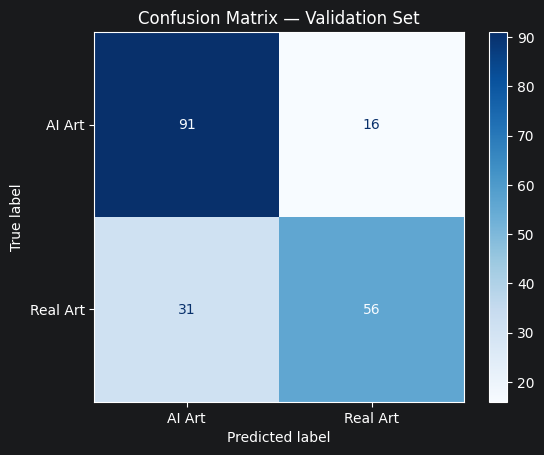

In [54]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

eval_gen = ImageDataGenerator(validation_split=0.2)

eval_data = eval_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False
)

y_pred_probs = model.predict(eval_data, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_data.classes

print(classification_report(y_true, y_pred, target_names=['AI Art', 'Real Art']))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AI Art', 'Real Art'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.show()

## Task 2b: Classifying 5 New Images

For Task 2b we test the trained model on five AI-generated images stored locally in `task2b_aiart_images/`.  
Since all five images are AI-generated, the true label for every image is `AiArtData` (class index 0).

The trained model is loaded from the local file `art_classifier.keras` produced in Phase 2 above.  
Each image is resized to 224×224 and loaded as RGB, matching the preprocessing used during training.  
No manual pixel rescaling is applied — EfficientNetB0 includes its own internal preprocessing when called with pretrained ImageNet weights.

The model outputs a sigmoid score:
- < 0.5 is predicted AI-generated
- ≥ 0.5 is predicted human-made

In [55]:
from pathlib import Path
import pandas as pd

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import accuracy_score

MODEL_PATH    = Path('art_classifier.keras')
AI_IMAGE_DIR  = Path('task2b_aiart_images')
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

assert MODEL_PATH.exists(),   f"Model not found: {MODEL_PATH}"
assert AI_IMAGE_DIR.exists(), f"Image folder not found: {AI_IMAGE_DIR}"

if 'model' not in dir() or model is None:
    model = load_model(MODEL_PATH, compile=False)
    print('Loaded model from', MODEL_PATH)
else:
    print('Using model already in memory.')

ai_image_paths = sorted(
    p for p in AI_IMAGE_DIR.rglob('*')
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXT
)

print(f'Found {len(ai_image_paths)} images in {AI_IMAGE_DIR}')
for p in ai_image_paths:
    print(' ', p)

Using model already in memory.
Found 5 images in task2b_aiart_images
  task2b_aiart_images/aiart.jpeg
  task2b_aiart_images/aiart.webp
  task2b_aiart_images/aiart1.jpeg
  task2b_aiart_images/aiart2.png
  task2b_aiart_images/airart3.jpeg


In [56]:
class_indices  = {'AiArtData': 0, 'RealArt': 1}
index_to_class = {v: k for k, v in class_indices.items()}

def prepare_image(path):
    img   = load_img(path, target_size=IMG_SIZE)
    array = img_to_array(img)
    return array

image_batch       = np.stack([prepare_image(p) for p in ai_image_paths])
prob_real         = model.predict(image_batch, verbose=0).reshape(-1)
predicted_indices = (prob_real >= 0.5).astype(int)

true_labels  = ['AiArtData'] * len(ai_image_paths)
true_indices = [class_indices[l] for l in true_labels]

results = pd.DataFrame({
    'image':                [p.name for p in ai_image_paths],
    'true_label':           true_labels,
    'probability_real_art': prob_real,
    'predicted_label':      [index_to_class[i] for i in predicted_indices],
})
results['correct']    = results['true_label'] == results['predicted_label']
results['confidence'] = np.where(
    predicted_indices == 1,
    results['probability_real_art'],
    1 - results['probability_real_art']
)

accuracy = accuracy_score(true_indices, predicted_indices)
print(f'Accuracy on {len(ai_image_paths)} new images: {accuracy:.2%}')
display(results)

print(classification_report(
    true_indices, predicted_indices,
    labels=[0, 1],
    target_names=[index_to_class[0], index_to_class[1]],
    zero_division=0,
))

Accuracy on 5 new images: 100.00%


,image,true_label,probability_real_art,predicted_label,correct,confidence
0,aiart.jpeg,AiArtData,0.019827,AiArtData,True,0.980173
1,aiart.webp,AiArtData,0.049396,AiArtData,True,0.950604
2,aiart1.jpeg,AiArtData,0.061747,AiArtData,True,0.938253
3,aiart2.png,AiArtData,0.141655,AiArtData,True,0.858345
4,airart3.jpeg,AiArtData,0.247075,AiArtData,True,0.752925


              precision    recall  f1-score   support

   AiArtData       1.00      1.00      1.00         5
     RealArt       0.00      0.00      0.00         0

    accuracy                           1.00         5
   macro avg       0.50      0.50      0.50         5
weighted avg       1.00      1.00      1.00         5



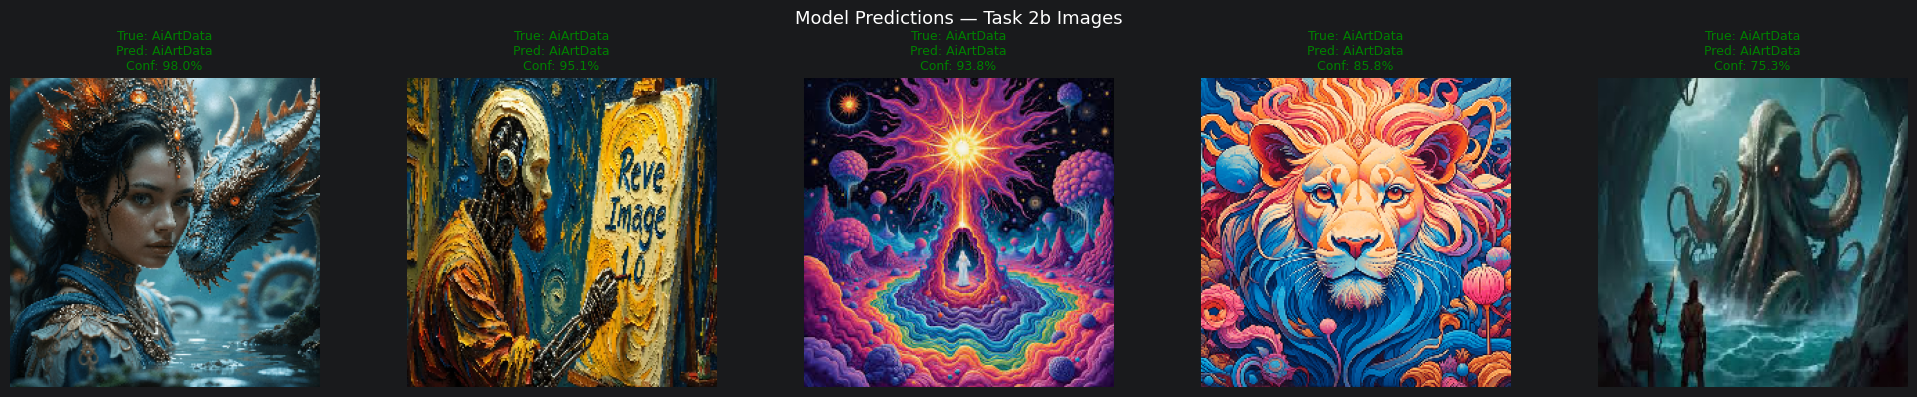

In [57]:
fig, axes = plt.subplots(1, len(ai_image_paths), figsize=(4 * len(ai_image_paths), 4))
if len(ai_image_paths) == 1:
    axes = [axes]

for ax, image_path, (_, row) in zip(axes, ai_image_paths, results.iterrows()):
    ax.imshow(load_img(image_path, target_size=IMG_SIZE))
    ax.axis('off')
    color = 'green' if row['correct'] else 'red'
    ax.set_title(
        f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.1%}",
        color=color, fontsize=9
    )

plt.suptitle('Model Predictions — Task 2b Images', fontsize=13)
plt.tight_layout()
plt.show()

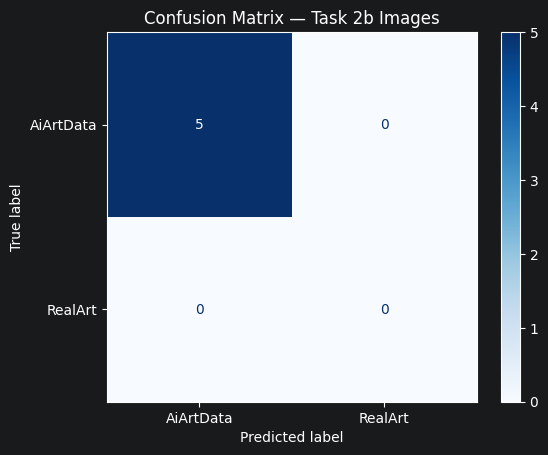

In [58]:
cm   = confusion_matrix(true_indices, predicted_indices, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[index_to_class[0], index_to_class[1]])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Task 2b Images')
plt.show()

## Summary and Discussion

### Results

The model achieves 75% validation accuracy on the held-out validation set (194 images). The best validation accuracy observed during training was 77.8%, from which EarlyStopping restored weights. The small gap between this and the final evaluation score reflects normal variation between the shuffled training generator and the fixed evaluation set. Given the small dataset size and the inherent difficulty of the task, 75% is a reasonable result.

### Class-wise performance

The classification report reveals an asymmetry between classes:
- AI Art (precision 74%, recall 84%) — the model is effective at detecting AI-generated images, but at the cost of misclassifying some real images as AI
- Real Art (precision 76%, recall 63%) — the model is more cautious here, missing 37% of genuine human-made images

This asymmetry is consistent with the mild class imbalance (55% AI, 45% real): the model learns a slight bias toward the majority class.

### Overfitting analysis

The training curves show a moderate overfitting pattern: training accuracy climbs to ~86% while validation accuracy plateaus around 77–79%. This gap is smaller than might be expected for a dataset of this size, which suggests the regularization measures were effective. EarlyStopping triggered early in both phases, after epoch 5 in Phase 1 and epoch 4 in Phase 2, preventing further divergence between training and validation performance.

Mitigation strategies applied:
- **Dropout (0.3)** in the classification head
- **Data augmentation** (rotation, horizontal flip, zoom)
- **EarlyStopping** with `restore_best_weights=True`

Further improvements that were not pursued due to resource constraints:
- More aggressive augmentation (color jitter, random cropping)
- L2 weight regularization in the dense layer
- A larger dataset would be the most impactful fix

### Fine-tuning assessment

Phase 2 fine-tuning produced only marginal gains over Phase 1, with EarlyStopping restoring weights from epoch 1 of Phase 2. Effectively the model improved very little during fine-tuning. This suggests the frozen ImageNet features were already well-suited to the task, and that the primary bottleneck is dataset size rather than feature quality.

### Consequences and limitations

Deployed in a real context, a 75% accurate classifier would misclassify 1 in 4 images. For a task like art attribution, which can have real consequences for artists, galleries, or copyright proceedings, this error rate is non-trivial. The model should be treated as a supporting tool rather than a definitive classifier. Additionally, the model was trained on a specific distribution of AI-generated art; it may not generalize well to images from newer generative models not represented in the training data.